# Multivariate bootstrap: keeping series in step

Real macro and financial data come as several series at once: output and
consumption, two interest rates, a basket of asset returns. What makes them
multivariate is that the columns move together, not merely that there are several
of them. A bootstrap of multivariate data is only useful if it keeps that joint
structure intact.

In `tsbootstrap`, multivariate input is an array of shape `(n, d)`: `n`
time steps, `d` series. Two ideas preserve the cross-series structure:

1. Row-resampling methods (the block family, and IID) resample whole rows, so
   the contemporaneous relationship between columns at a given time is carried
   along untouched.
2. `ResidualBootstrap(model=VAR(order=...))` fits a vector autoregression, which
   models how each series depends on the recent past of every series, then
   simulates new paths forward. This captures the dynamic, lead-lag structure
   that row-resampling within a single time step cannot.

We work both ideas through on a synthetic VAR(1) with known structure and on a real
macro subset, and pin down where the simple methods fall short.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## A synthetic bivariate VAR(1) with known structure

We generate a two-series VAR(1), `X[t] = A @ X[t-1] + e[t]`, where the
coefficient matrix `A` and the innovation covariance are ours to choose, so every
correlation we measure later has a ground truth. Two channels carry the joint
structure:

- contemporaneous: the innovations `e[t]` are correlated across the two series
  (off-diagonal of the covariance), so the columns co-move at the same instant;
- dynamic: `A` is not diagonal, so each series depends on the recent past of the
  other. Here series 1 feeds into series 0, a lead-lag relationship.

X shape: (200, 2)  (n time steps, d series)


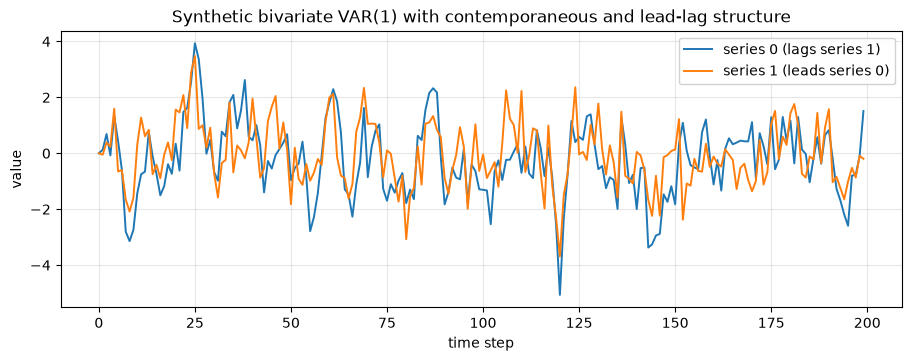

In [2]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)
n = 200

# Coefficient matrix: x0 picks up the lagged value of x1 (x1 leads x0).
A = np.array([[0.5, 0.3], [0.0, 0.5]])

# Innovation covariance: positive contemporaneous correlation between the series.
cov = np.array([[1.0, 0.5], [0.5, 1.0]])
chol = np.linalg.cholesky(cov)

X = np.zeros((n, 2))
for t in range(1, n):
    X[t] = A @ X[t - 1] + chol @ rng.standard_normal(2)

print("X shape:", X.shape, " (n time steps, d series)")

fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
ax.plot(X[:, 0], color="tab:blue", lw=1.4, label="series 0 (lags series 1)")
ax.plot(X[:, 1], color="tab:orange", lw=1.4, label="series 1 (leads series 0)")
ax.set_title("Synthetic bivariate VAR(1) with contemporaneous and lead-lag structure")
ax.set_xlabel("time step")
ax.set_ylabel("value")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", framealpha=0.9)
plt.show()

## Two kinds of cross-correlation

We will track two summaries of the joint structure throughout:

- contemporaneous cross-correlation, `corr(x0[t], x1[t])`, the off-diagonal of
  the correlation matrix of the columns;
- lag-1 cross-correlation, `corr(x0[t], x1[t-1])`, which is non-zero precisely
  because series 1 leads series 0 through the coefficient matrix.

A faithful multivariate bootstrap should reproduce both.

In [3]:
def contemp_cross_corr(series):
    """Off-diagonal of the column correlation matrix: corr(x0[t], x1[t])."""
    return float(np.corrcoef(np.asarray(series).T)[0, 1])


def lag1_cross_corr(series):
    """corr(x0[t], x1[t-1]): the lead of series 1 into series 0."""
    s = np.asarray(series, dtype=float)
    a, b = s[1:, 0], s[:-1, 1]
    a = a - a.mean()
    b = b - b.mean()
    return float(np.dot(a, b) / np.sqrt(np.dot(a, a) * np.dot(b, b)))


orig_contemp = contemp_cross_corr(X)
orig_lag1 = lag1_cross_corr(X)
print(f"original contemporaneous cross-corr corr(x0_t, x1_t)   : {orig_contemp:.3f}")
print(f"original lag-1 cross-corr        corr(x0_t, x1_(t-1))  : {orig_lag1:.3f}")

original contemporaneous cross-corr corr(x0_t, x1_t)   : 0.604
original lag-1 cross-corr        corr(x0_t, x1_(t-1))  : 0.528


## VAR residual bootstrap

`ResidualBootstrap(model=VAR(order=1))` fits the vector autoregression once, then
regenerates each replicate by resampling the fitted residuals and running the VAR
recursion forward. Because the fitted `A` encodes the lead-lag structure and the
residuals carry the contemporaneous innovation correlation, both kinds of
cross-correlation should survive into the replicates.

The replicates have the same `(n, d)` shape as the input, stacked into a
`(n_bootstraps, n, d)` array by `result.values()`. VAR requires `d >= 2`
series.

In [4]:
from tsbootstrap import VAR, ResidualBootstrap, bootstrap

var_res = bootstrap(
    X, method=ResidualBootstrap(model=VAR(order=1)), n_bootstraps=500, random_state=0
)
var_vals = var_res.values()
print("replicate array shape:", var_vals.shape, " (n_bootstraps, n, d)")
print("metadata n_series:", var_res.metadata.n_series)

var_contemp = np.array([contemp_cross_corr(v) for v in var_vals])
var_lag1 = np.array([lag1_cross_corr(v) for v in var_vals])

print()
print(f"{'':22s} {'original':>10s} {'VAR mean':>10s}")
print(f"{'contemporaneous corr':22s} {orig_contemp:10.3f} {var_contemp.mean():10.3f}")
print(f"{'lag-1 corr':22s} {orig_lag1:10.3f} {var_lag1.mean():10.3f}")

replicate array shape: (500, 200, 2)  (n_bootstraps, n, d)
metadata n_series: 2

                         original   VAR mean
contemporaneous corr        0.604      0.595
lag-1 corr                  0.528      0.515


The VAR replicates recover both summaries. The contemporaneous correlation is
inherited from the resampled residuals, and the lag-1 correlation comes back
because the recursion replays the fitted coefficient matrix. Modelling the joint
dynamics is what buys the second number; resampling the columns in isolation
would not.

## Block methods on multivariate input

The block family also accepts `(n, d)` input directly. A block bootstrap copies
contiguous blocks of *rows*, so the columns inside each block stay locked
together. That keeps the contemporaneous correlation exactly, and it keeps the
within-block dynamics, which is enough to reproduce short-lag cross-correlation
too. No model is fitted, so this is the robust choice when you do not want to
commit to a VAR.

In [5]:
from tsbootstrap import MovingBlock, StationaryBlock

block_specs = {
    "MovingBlock": MovingBlock(block_length="auto"),
    "StationaryBlock": StationaryBlock(avg_block_length="auto"),
}

print(f"{'method':18s} {'shape':>18s} {'contemp':>9s} {'lag-1':>9s}")
print("-" * 56)
print(f"{'original':18s} {'':>18s} {orig_contemp:9.3f} {orig_lag1:9.3f}")
for name, spec in block_specs.items():
    res = bootstrap(X, method=spec, n_bootstraps=500, random_state=0)
    vals = res.values()
    contemp = np.mean([contemp_cross_corr(v) for v in vals])
    lag1 = np.mean([lag1_cross_corr(v) for v in vals])
    print(f"{name:18s} {str(vals.shape):>18s} {contemp:9.3f} {lag1:9.3f}")

method                          shape   contemp     lag-1
--------------------------------------------------------
original                                  0.604     0.528
MovingBlock             (500, 200, 2)     0.598     0.458
StationaryBlock         (500, 200, 2)     0.595     0.442


Both block methods return `(n_bootstraps, n, d)` arrays and reproduce the
contemporaneous and lag-1 cross-correlations. Resampling whole rows is what
preserves the joint structure.

## Where the naive choice fails

It is tempting to conclude that any row-resampler is fine for multivariate data.
For the *contemporaneous* correlation that holds: even plain IID resampling keeps
it, because it never splits a row. But IID shuffles rows independently, so it
destroys every relationship that spans more than one time step, including the
lead-lag cross-correlation. That gap is the reason to reach for a time-series
method on multivariate data instead of a plain resampler.

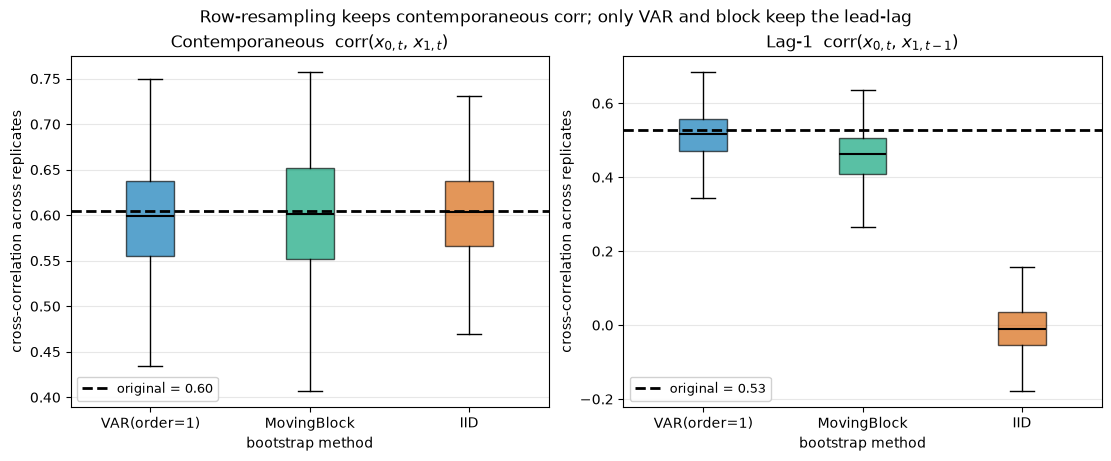

method          contemp mean  lag-1 mean
VAR(order=1)           0.595       0.515
MovingBlock            0.598       0.458
IID                    0.601      -0.009
original               0.604       0.528


In [6]:
from tsbootstrap import IID

methods = {
    "VAR(order=1)": ResidualBootstrap(model=VAR(order=1)),
    "MovingBlock": MovingBlock(block_length="auto"),
    "IID": IID(),
}

contemp_by_method, lag1_by_method = {}, {}
for name, spec in methods.items():
    vals = bootstrap(X, method=spec, n_bootstraps=500, random_state=0).values()
    contemp_by_method[name] = np.array([contemp_cross_corr(v) for v in vals])
    lag1_by_method[name] = np.array([lag1_cross_corr(v) for v in vals])

names = list(methods)
# Colorblind-friendly per-method colors (Okabe-Ito subset).
method_colors = {"VAR(order=1)": "#0072B2", "MovingBlock": "#009E73", "IID": "#D55E00"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, data, orig, title in [
    (axes[0], contemp_by_method, orig_contemp, "Contemporaneous  corr($x_{0,t}$, $x_{1,t}$)"),
    (axes[1], lag1_by_method, orig_lag1, "Lag-1  corr($x_{0,t}$, $x_{1,t-1}$)"),
]:
    bp = ax.boxplot(
        [data[k] for k in names],
        tick_labels=names,
        showfliers=False,
        patch_artist=True,
        medianprops={"color": "black", "lw": 1.5},
    )
    for patch, name in zip(bp["boxes"], names):
        patch.set_facecolor(method_colors[name])
        patch.set_alpha(0.65)
    ax.axhline(orig, color="black", lw=2, ls="--", label=f"original = {orig:.2f}")
    ax.set_title(title)
    ax.set_xlabel("bootstrap method")
    ax.set_ylabel("cross-correlation across replicates")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
fig.suptitle(
    "Row-resampling keeps contemporaneous corr; only VAR and block keep the lead-lag",
    fontsize=12,
)
plt.show()

print(f"{'method':14s} {'contemp mean':>13s} {'lag-1 mean':>11s}")
for name in names:
    print(f"{name:14s} {contemp_by_method[name].mean():13.3f} {lag1_by_method[name].mean():11.3f}")
print(f"original       {orig_contemp:13.3f} {orig_lag1:11.3f}")

The left panel is flat: all three methods land on the original
contemporaneous correlation, because none of them splits a row. The right panel
separates them. VAR and the moving block sit on the dashed lead-lag truth; IID
collapses to zero. IID has thrown away the dynamic cross-dependence while keeping
the static one, the kind of silent failure to watch for.

## A real macro example

We repeat the check on a small macro subset from `statsmodels`: real GDP, real
consumption, and the CPI (quarterly US data). The levels trend upward and are
non-stationary, so we work with quarterly log growth rates, which a VAR can fit
sensibly. The truth is no longer known, but we can still confirm that the
replicate cross-correlations track the observed ones.

In [7]:
import pandas as pd
import statsmodels.api as sm

macro = sm.datasets.macrodata.load_pandas().data
levels = macro[["realgdp", "realcons", "cpi"]].to_numpy()
labels = ["realgdp", "realcons", "cpi"]

# Quarterly log growth (in percent): a stationary multivariate series.
growth = np.diff(np.log(levels), axis=0) * 100.0
print("growth shape:", growth.shape, " (n, d)")

orig_corr = np.corrcoef(growth.T)
print("original cross-correlation matrix:")
pd.DataFrame(orig_corr, index=labels, columns=labels).round(3)

growth shape: (202, 3)  (n, d)
original cross-correlation matrix:


,realgdp,realcons,cpi
realgdp,1.000,0.658,-0.059
realcons,0.658,1.000,-0.171
cpi,-0.059,-0.171,1.000


We fit a VAR(2) on the growth rates, average the replicate correlation matrices,
and compare them against the original. The two matrices appear side by side as
heatmaps, with the off-diagonal pairs collected into a table below.

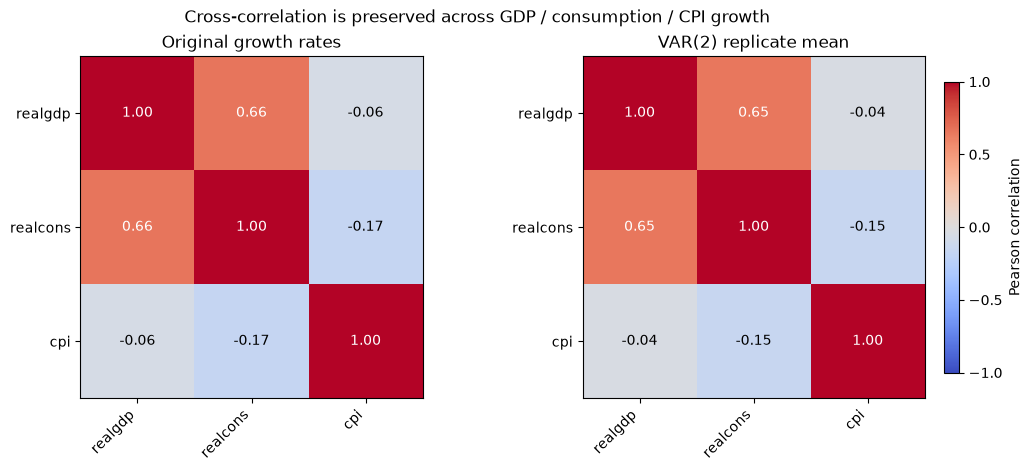

,pair,original,VAR(2) replicate mean,difference
0,realgdp / realcons,0.658,0.652,-0.006
1,realgdp / cpi,-0.059,-0.041,0.018
2,realcons / cpi,-0.171,-0.149,0.022


In [8]:
import pandas as pd

macro_res = bootstrap(
    growth,
    method=ResidualBootstrap(model=VAR(order=2)),
    n_bootstraps=500,
    random_state=0,
)
macro_corr = np.mean([np.corrcoef(v.T) for v in macro_res.values()], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
for ax, mat, title in [
    (axes[0], orig_corr, "Original growth rates"),
    (axes[1], macro_corr, "VAR(2) replicate mean"),
]:
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_title(title)
    # Annotate each cell; pick black or white text for contrast against the fill.
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = mat[i, j]
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color="white" if abs(val) > 0.6 else "black",
            )
cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label("Pearson correlation")
cbar.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])
fig.suptitle(
    "Cross-correlation is preserved across GDP / consumption / CPI growth",
    fontsize=12,
)
plt.show()

# Off-diagonal pairs side by side: original vs replicate mean.
pairs = [(0, 1), (0, 2), (1, 2)]
comparison = pd.DataFrame(
    {
        "pair": [f"{labels[i]} / {labels[j]}" for i, j in pairs],
        "original": [orig_corr[i, j] for i, j in pairs],
        "VAR(2) replicate mean": [macro_corr[i, j] for i, j in pairs],
    }
)
comparison["difference"] = comparison["VAR(2) replicate mean"] - comparison["original"]
comparison.round(3)

The two heatmaps match: the strong GDP-consumption co-movement and the weak,
slightly negative links to CPI growth all carry over into the VAR replicates.
The bootstrap has preserved the joint structure of the real series, not just the
marginals.

## `diagnose()` on multivariate input

`diagnose()` inspects the series and recommends method specifications. When it
sees more than one column it adds a VAR-based recommendation, because a VAR is
the model-based way to capture cross-series dependence, while noting that block
methods preserve it by resampling whole rows. We run it on both the
non-stationary levels and the stationary growth rates.

In [9]:
from tsbootstrap import diagnose

for name, series in [("macro levels", levels), ("macro growth", growth)]:
    d = diagnose(series)
    print(f"{name} (n_series={d.n_series}):")
    print(f"  recommended: {d.recommended_methods}")
    for note in d.notes:
        print(f"  - {note}")
    print()

macro levels (n_series=3):
  recommended: ('ResidualBootstrap(model=VAR(...))', 'ResidualBootstrap(model=ARIMA(...))', 'SieveAR')
  - Series looks non-stationary (unit root): difference it via ARIMA, or use the sieve.
  - Multivariate input: VAR captures cross-series dependence; block methods preserve it by resampling whole rows.

macro growth (n_series=3):
  recommended: ('ResidualBootstrap(model=VAR(...))', 'StationaryBlock', 'MovingBlock', 'SieveAR')
  - Serial dependence present (lag-1 autocorrelation 0.64): use a block method or the sieve.
  - Multivariate input: VAR captures cross-series dependence; block methods preserve it by resampling whole rows.
  - Suggested automatic block length (Politis-White): 20.



For both the levels and the growth rates, `diagnose()` puts
`ResidualBootstrap(model=VAR(...))` first, because the input is multivariate. The
rest of the recommendation reflects what else it measured: an integrated model
for the trending levels (a unit root), block methods and the sieve for the
stationary growth rates. The multivariate signal is detected from the column
count alone, so it fires regardless of the stationarity verdict.

### Choosing for multivariate input

Multivariate data is defined by how its series move together, so a bootstrap
must preserve that joint structure. Row-resampling methods (the block family)
keep it by copying whole rows of `(n, d)` input, which is robust and
model-free. `ResidualBootstrap(model=VAR(...))` keeps it by fitting and replaying
the vector dynamics, which additionally captures lead-lag relationships that a
single-step resampler cannot. Plain IID keeps the contemporaneous correlation
but discards the dynamics, so on data with real lead-lag structure a time-series
method earns its keep. `diagnose()` flags the multivariate case for you and
points at the VAR.